In [1]:
!pip install pandas numpy matplotlib wordcloud deep_translator pyvi emoji


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\ACER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Import các hàm từ file src/preprocessing.py chúng ta vừa tạo
from src.preprocessing import apply_translation, preprocess_pipeline, plot_wordcloud, plot_doc_length

# Cấu hình hiển thị (tùy chọn)
%matplotlib inline

C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyvi\ViTokenizer.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  model = pickle.load(fin)


In [ ]:
# Đường dẫn file gốc
input_path = 'data/reviewjob.csv' 
# Đường dẫn file sẽ lưu sau khi xử lý
output_path = 'data/topic_modeling_data.csv'

df = pd.read_csv(input_path)
print(f"Dữ liệu gốc có {df.shape[0]} dòng.")
df.head()

Dữ liệu gốc có 3794 dòng.


,content
0,CV của một bạn nữ fresher mới ra trường với mi...
1,"- Phần “About me” ngắn gọn, đi thẳng vào trọng..."
2,1.5 năm kinh nghiệm và các impact cụ thể. Đây ...
3,+ Bằng Cử nhân QTKD GPA 8.34 là một lợi thế.\n...
4,"+ Cover 3 ngành: E-Commerce, Transport/Deliver..."


In [4]:
# Gọi hàm từ src
df = apply_translation(df, col_name='content') # Thay 'content' bằng tên cột của bạn
df.head()

--- Bắt đầu dịch thuật ---


,content
0,CV của một bạn nữ Fresher mới ra trường với tư...
1,"- Phần “Giới thiệu về tôi” ngắn gọn, đi thẳng ..."
2,"1,5 năm kinh nghiệm và các công cụ tác động. Đ..."
3,"+ Bằng cử nhân QTKD GPA 8,34 là một lợi ích.\n..."
4,"+ Bao gồm 3 chuyên ngành: Thương mại điện tử, ..."


In [5]:
# Cell 4: Làm sạch dữ liệu

# Lưu ý: Bạn phải chắc chắn file vietnamese-stopwords.txt đang nằm trong folder data
stopwords_file = 'data/vietnamese-stopwords.txt'

# Gọi hàm pipeline
df = preprocess_pipeline(df, col_name='content', stopwords_path=stopwords_file)

# Kiểm tra
df[['content', 'clean_text']].head()

--- Bắt đầu tiền xử lý (Tokenization & Normalization) ---
--- Đang chạy bộ lọc nâng cao (Super Filter) ---
Hoàn tất. Dữ liệu gốc: 3794 -> Còn lại: 3241 dòng.


,content,clean_text
0,CV của một bạn nữ Fresher mới ra trường với tư...,hồ_sơ nữ fresher trường tư_duy cực đỉnh bố_cục...
1,"- Phần “Giới thiệu về tôi” ngắn gọn, đi thẳng ...",giới_thiệu ngắn_gọn đi thẳng trọng_tâm vai_trò...
2,"1,5 năm kinh nghiệm và các công cụ tác động. Đ...",kinh_nghiệm công_cụ tác_động kiểu tóm_tắt điều...
3,"+ Bằng cử nhân QTKD GPA 8,34 là một lợi ích.\n...",cử_nhân qtkd gpa lợi_ích chứng_chỉ product own...
4,"+ Bao gồm 3 chuyên ngành: Thương mại điện tử, ...",bao_gồm chuyên_ngành thương_mại điện_tử_vận_tả...


--- Biểu đồ WordCloud trước preprocessing ---


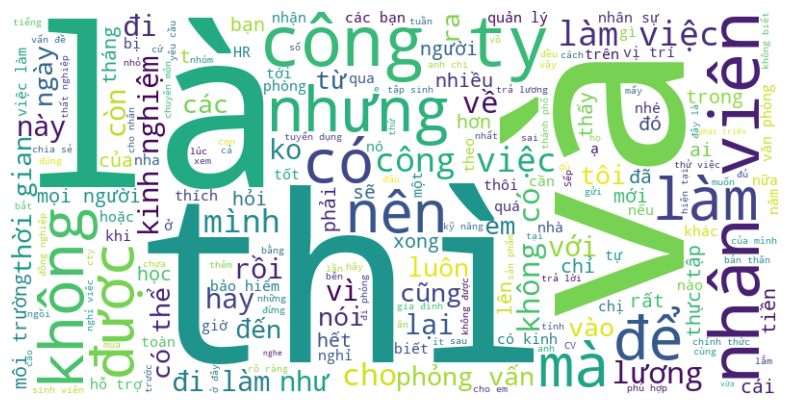

In [8]:
print("--- Biểu đồ WordCloud trước preprocessing ---")
plot_wordcloud(df['content'])

--- Biểu đồ WordCloud ---


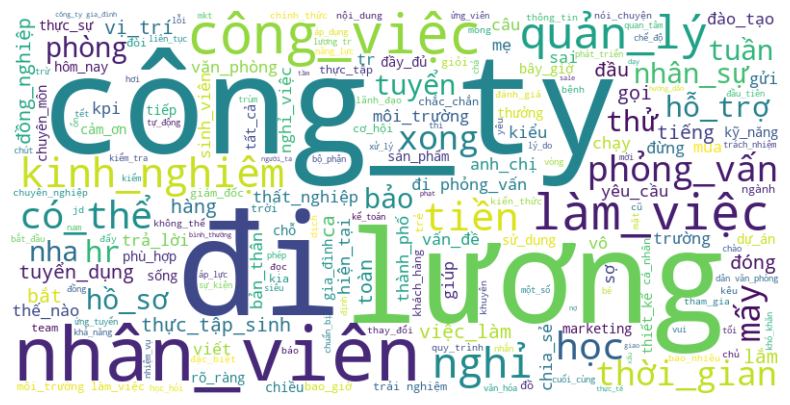

--- Phân bố độ dài văn bản ---


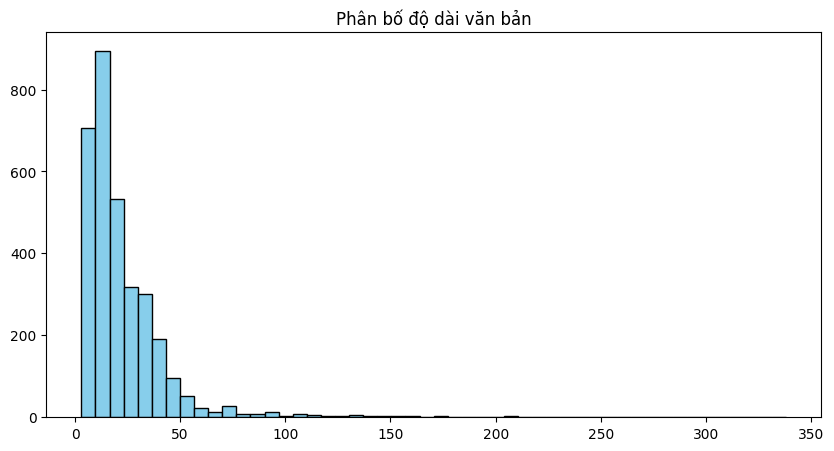

In [6]:
print("--- Biểu đồ WordCloud ---")
plot_wordcloud(df['clean_text'])

print("--- Phân bố độ dài văn bản ---")
plot_doc_length(df['clean_text'])

In [ ]:
def token_count(tokens):
    return len(tokens)
df["token_count"] = df["tokens"].apply(token_count)
plt.figure(figsize=(8,5))
sns.histplot(df["token_count"], bins=40, kde=True, color='red')
plt.title("Phân phối số lượng token")
plt.xlabel("số lượng token")
plt.ylabel("tần số")
plt.show()

In [ ]:
from collections import Counter
token_freq = Counter([w for tokens in df["tokens"] for w in tokens])
top20 = token_freq.most_common(20)
for w,c in top20:
    print(w,":",c)
words, counts = zip(*top20)

plt.figure(figsize=(8,6))
sns.barplot(x=list(counts), y=list(words))
plt.title("Top 20 từ xuất hiện nhiều nhất")
plt.xlabel("số lượng")
plt.ylabel("token")
plt.show()